   Movie_ID  Year                          Name
0         1  2003               Dinosaur Planet
1         2  2004    Isle of Man TT 2004 Review
2         3  1997                     Character
3         4  1994  Paula Abdul's Get Up & Dance
4         5  2004      The Rise and Fall of ECW
   User_ID  Rating  Movie_ID
0   712664       5         3
1  1331154       4         3
2  2632461       3         3
3    44937       5         3
4   656399       4         3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Movie_ID  17770 non-null  int64 
 1   Year      17770 non-null  int64 
 2   Name      17770 non-null  object
dtypes: int64(2), object(1)
memory usage: 416.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17337458 entries, 0 to 17337457
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   User_ID   int64
 1   R

C:\Users\ASTALAKSHMI\AppData\Local\Temp\ipykernel_20676\2461986348.py:37: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  movies.fillna(method='ffill', inplace=True)


   Movie_ID  Avg_Rating  Rating_Count  Popularity
0         3    3.621391          1524      5519.0
1         8    3.136795          9379     29420.0
2        16    3.081843          2517      7757.0
3        17    2.909964          4165     12120.0
4        18    3.767597          9419     35487.0


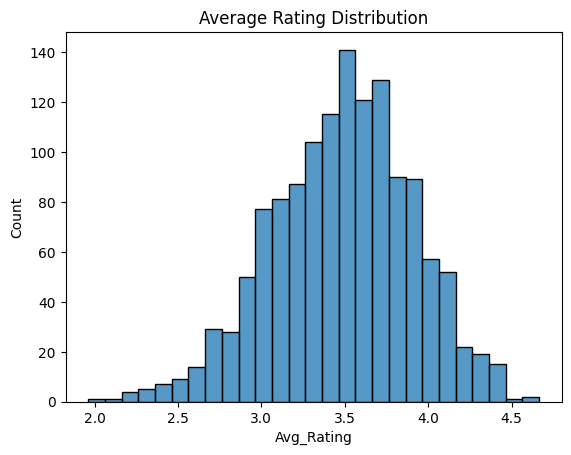

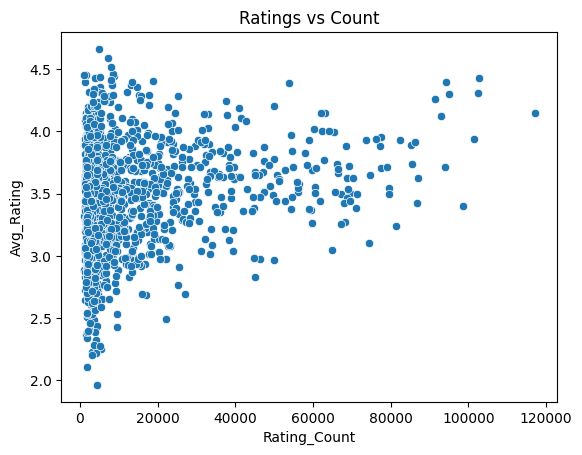

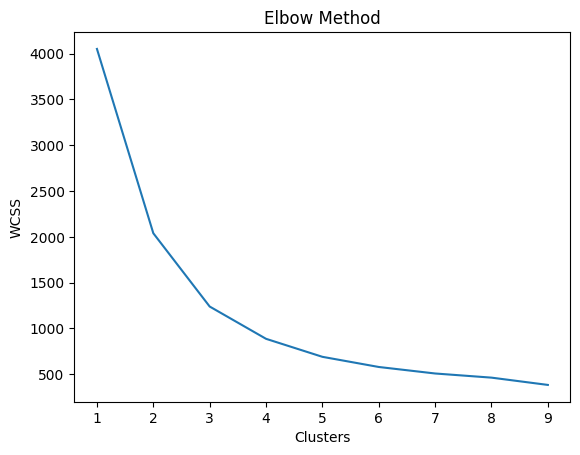

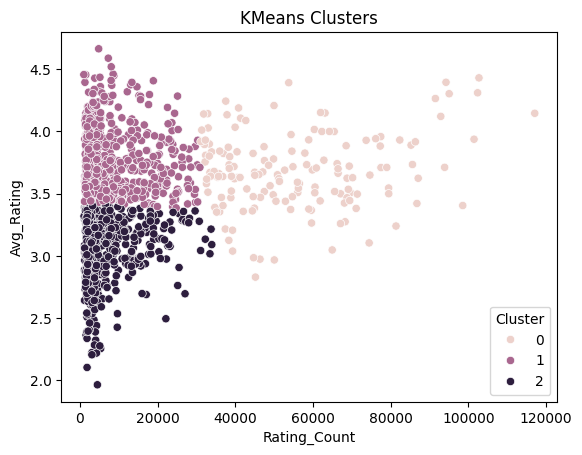

Silhouette Score: 0.4344095709321176


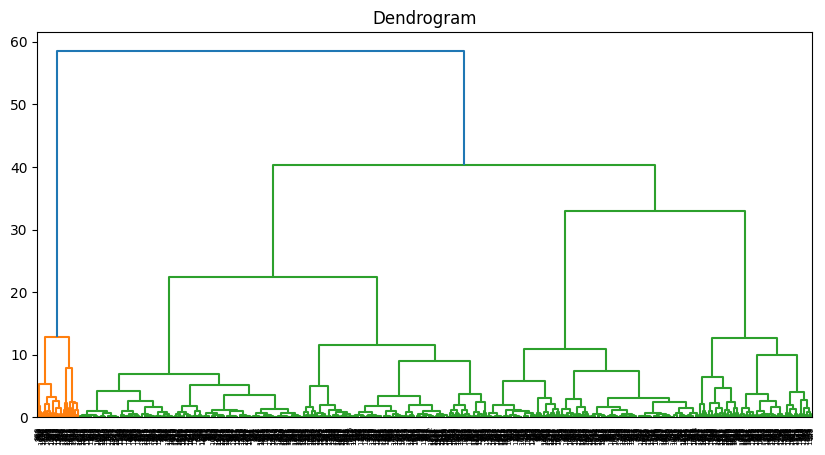

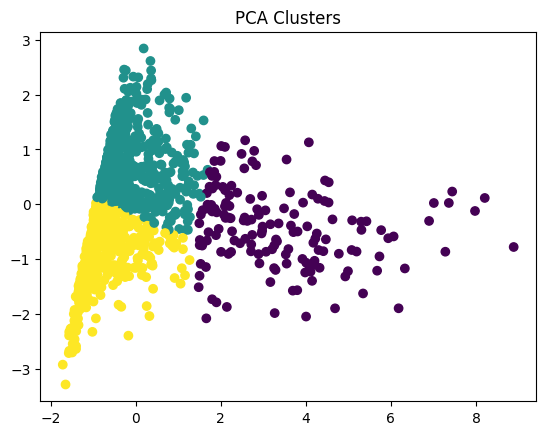

ValueError: Movie 1 not found in the dataset.

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage

import pickle

# ==============================
# 2. LOAD DATA
# ==============================
movies = pd.read_csv("Netflix_Dataset_Movie.csv")
ratings = pd.read_csv("Netflix_Dataset_Rating.csv")

print(movies.head())
print(ratings.head())

# ==============================
# 3. DATA CLEANING
# ==============================
print(movies.info())
print(ratings.info())

movies.ffill(inplace=True)
ratings.dropna(inplace=True)

# ==============================
# 4. MERGE DATASETS
# ==============================
data = pd.merge(ratings, movies, on="Movie_ID")

# ==============================
# 5. FEATURE ENGINEERING
# ==============================
movie_avg_rating = data.groupby("Movie_ID")["Rating"].mean().reset_index()
movie_avg_rating.rename(columns={"Rating": "Avg_Rating"}, inplace=True)

movie_rating_count = data.groupby("Movie_ID")["Rating"].count().reset_index()
movie_rating_count.rename(columns={"Rating": "Rating_Count"}, inplace=True)

movie_features = pd.merge(movie_avg_rating, movie_rating_count, on="Movie_ID")

# Extra feature
movie_features["Popularity"] = movie_features["Avg_Rating"] * movie_features["Rating_Count"]

print(movie_features.head())

# ==============================
# 6. VISUALIZATION
# ==============================
plt.figure()
sns.histplot(movie_features["Avg_Rating"])
plt.title("Average Rating Distribution")
plt.show()

plt.figure()
sns.scatterplot(x="Rating_Count", y="Avg_Rating", data=movie_features)
plt.title("Ratings vs Count")
plt.show()

# ==============================
# 7. SCALING
# ==============================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(movie_features[["Avg_Rating", "Rating_Count", "Popularity"]])

# ==============================
# 8. K-MEANS CLUSTERING
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
movie_features["Cluster"] = kmeans.fit_predict(scaled_data)

# ==============================
# 9. ELBOW METHOD
# ==============================
wcss = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# ==============================
# 10. CLUSTER VISUALIZATION
# ==============================
plt.figure()
sns.scatterplot(
    x=movie_features["Rating_Count"],
    y=movie_features["Avg_Rating"],
    hue=movie_features["Cluster"]
)
plt.title("KMeans Clusters")
plt.show()

# ==============================
# 11. SILHOUETTE SCORE
# ==============================
score = silhouette_score(scaled_data, movie_features["Cluster"])
print("Silhouette Score:", score)

# ==============================
# 12. HIERARCHICAL CLUSTERING
# ==============================
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

# ==============================
# 13. DBSCAN
# ==============================
dbscan = DBSCAN(eps=0.5, min_samples=5)
movie_features["DBSCAN_Cluster"] = dbscan.fit_predict(scaled_data)

# ==============================
# 14. PCA
# ==============================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=movie_features["Cluster"])
plt.title("PCA Clusters")
plt.show()

# ==============================
# 15. RECOMMENDATION SYSTEM ⭐
# ==============================

from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors

# Build a sparse movie-user matrix directly from the rating data
movie_ids = data["Movie_ID"].unique()
user_ids = data["User_ID"].unique()
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}

rows = data["Movie_ID"].map(movie_to_idx)
cols = data["User_ID"].map(user_to_idx)
values = data["Rating"].astype(float)

movie_user_sparse = coo_matrix(
    (values, (rows, cols)),
    shape=(len(movie_ids), len(user_ids))
).tocsr()

# Fit a nearest-neighbors model on movie vectors
nn = NearestNeighbors(metric="cosine", algorithm="brute", n_jobs=-1)
nn.fit(movie_user_sparse)

# Recommendation function using cosine-based movie similarity

def recommend_movies(movie_id, n=5):
    if movie_id not in movie_to_idx:
        raise ValueError(f"Movie {movie_id} not found in the dataset.")
    idx = movie_to_idx[movie_id]
    distances, indices = nn.kneighbors(movie_user_sparse[idx], n_neighbors=n + 1)

    similar_movie_ids = []
    similar_scores = []
    for dist, movie_idx in zip(distances.flatten(), indices.flatten()):
        if movie_idx == idx:
            continue
        similar_movie_ids.append(movie_ids[movie_idx])
        similar_scores.append(1.0 - dist)
        if len(similar_movie_ids) == n:
            break

    return pd.Series(similar_scores, index=similar_movie_ids, name="Similarity")

print("Recommended Movies:\n", recommend_movies(1))

# ==============================
# 16. CLASSIFICATION
# ==============================
movie_features["Label"] = (movie_features["Avg_Rating"] > 3).astype(int)

X = movie_features[["Rating_Count", "Popularity"]]
y = movie_features["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

# ==============================
# 17. REGRESSION
# ==============================
X_reg = movie_features[["Rating_Count", "Popularity"]]
y_reg = movie_features["Avg_Rating"]

reg = LinearRegression()
reg.fit(X_reg, y_reg)

print("Regression Coefficients:", reg.coef_)

# ==============================
# 18. SAVE MODELS
# ==============================
pickle.dump(kmeans, open("kmeans_model.pkl", "wb"))
pickle.dump(clf, open("classifier_model.pkl", "wb"))
pickle.dump(reg, open("regression_model.pkl", "wb"))

print("Models Saved Successfully!")

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
movies = pd.read_csv("Netflix_Dataset_Movie.csv")
ratings = pd.read_csv("Netflix_Dataset_Rating.csv")

print(movies.head())
print(ratings.head())

   Movie_ID  Year                          Name
0         1  2003               Dinosaur Planet
1         2  2004    Isle of Man TT 2004 Review
2         3  1997                     Character
3         4  1994  Paula Abdul's Get Up & Dance
4         5  2004      The Rise and Fall of ECW
   User_ID  Rating  Movie_ID
0   712664       5         3
1  1331154       4         3
2  2632461       3         3
3    44937       5         3
4   656399       4         3


In [43]:
movies.fillna(method='ffill', inplace=True)
ratings.dropna(inplace=True)

C:\Users\ASTALAKSHMI\AppData\Local\Temp\ipykernel_20676\1512239755.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  movies.fillna(method='ffill', inplace=True)


In [44]:
data = pd.merge(ratings, movies, on="Movie_ID")
print(data.head())

   User_ID  Rating  Movie_ID  Year       Name
0   712664       5         3  1997  Character
1  1331154       4         3  1997  Character
2  2632461       3         3  1997  Character
3    44937       5         3  1997  Character
4   656399       4         3  1997  Character


In [45]:
data = data.sample(n=5000, random_state=42)

In [46]:
movie_avg = data.groupby("Movie_ID")["Rating"].mean().reset_index()
movie_avg.rename(columns={"Rating": "Avg_Rating"}, inplace=True)

movie_count = data.groupby("Movie_ID")["Rating"].count().reset_index()
movie_count.rename(columns={"Rating": "Rating_Count"}, inplace=True)

movie_features = pd.merge(movie_avg, movie_count, on="Movie_ID")

movie_features["Popularity"] = movie_features["Avg_Rating"] * movie_features["Rating_Count"]

print(movie_features.head())

   Movie_ID  Avg_Rating  Rating_Count  Popularity
0         8         4.0             2         8.0
1        16         2.0             1         2.0
2        17         3.5             2         7.0
3        26         3.0             2         6.0
4        28         4.0             4        16.0


In [40]:
features = data[['Rating']]

In [36]:
from sklearn.preprocessing import StandardScaler

features = data[['Rating']]   # ✅ define features first

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

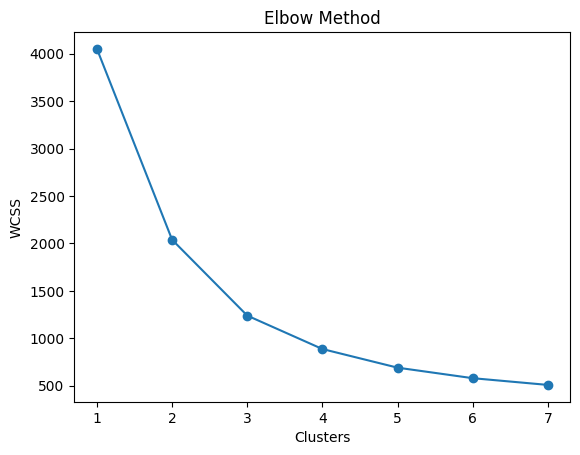

In [9]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 8):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1, 8), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

Feature Data:
    movieid  Avg_Rating  Rating_Count
0        3    3.621391          1524
1        8    3.136795          9379
2       16    3.081843          2517
3       17    2.909964          4165
4       18    3.767597          9419

KMeans Cluster Summary:
                Avg_Rating  Rating_Count
KMeans_Cluster                          
0                 3.663326  56837.186207
1                 3.088494   6910.000000
2                 3.782620   8088.431853

Hierarchical Cluster Summary:
                      Avg_Rating  Rating_Count
Hierarchical_Cluster                          
0                       3.599916   9737.621313
1                       3.717363  67743.483146
2                       2.817737   5114.514286

DBSCAN Cluster Summary:
                Avg_Rating   Rating_Count
DBSCAN_Cluster                           
-1                4.146334  117075.000000
 0                3.485497   12765.295033


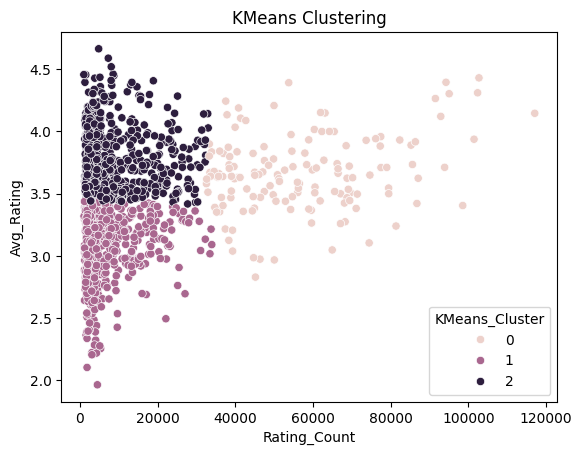

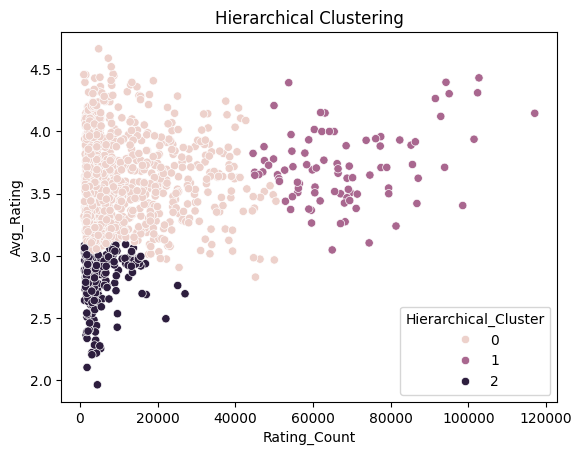

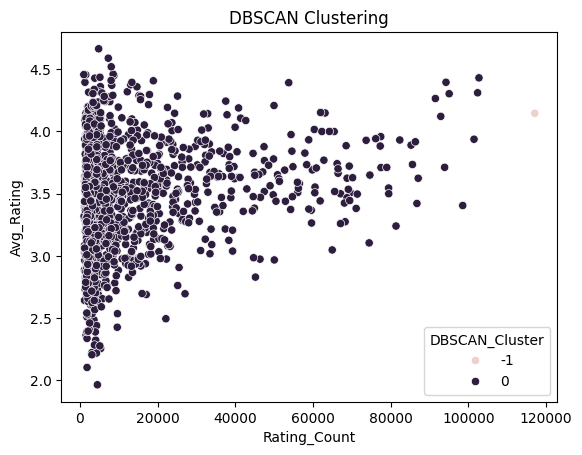

In [87]:
# =====================================
# STEP 1: IMPORT LIBRARIES
# =====================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================
# STEP 2: LOAD DATASETS
# =====================================
ratings = pd.read_csv("Netflix_Dataset_Rating.csv")
movies = pd.read_csv("Netflix_Dataset_Movie.csv")

# =====================================
# STEP 3: CLEAN COLUMN NAMES
# =====================================
ratings.columns = ratings.columns.str.lower().str.strip().str.replace(" ", "").str.replace("_", "")
movies.columns = movies.columns.str.lower().str.strip().str.replace(" ", "").str.replace("_", "")

# =====================================
# STEP 4: AUTO DETECT COLUMNS
# =====================================
movie_col_r = [col for col in ratings.columns if "movie" in col and "id" in col][0]
movie_col_m = [col for col in movies.columns if "movie" in col and "id" in col][0]
rating_col = [col for col in ratings.columns if "rating" in col][0]

ratings.rename(columns={movie_col_r: "movieid", rating_col: "rating"}, inplace=True)
movies.rename(columns={movie_col_m: "movieid"}, inplace=True)

# =====================================
# STEP 5: MERGE DATA
# =====================================
df = pd.merge(ratings, movies, on="movieid")

# =====================================
# STEP 6: FEATURE ENGINEERING
# =====================================
movie_features = df.groupby("movieid").agg(
    Avg_Rating=("rating", "mean"),
    Rating_Count=("rating", "count")
).reset_index()

print("Feature Data:\n", movie_features.head())

# =====================================
# STEP 7: SCALING
# =====================================
scaler = StandardScaler()
X = scaler.fit_transform(movie_features[["Avg_Rating", "Rating_Count"]])

# =====================================
# 🔥 METHOD 1: KMEANS CLUSTERING
# =====================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
movie_features["KMeans_Cluster"] = kmeans.fit_predict(X)

# =====================================
# 🔥 METHOD 2: HIERARCHICAL CLUSTERING
# =====================================
hc = AgglomerativeClustering(n_clusters=3)
movie_features["Hierarchical_Cluster"] = hc.fit_predict(X)

# =====================================
# 🔥 METHOD 3: DBSCAN CLUSTERING
# =====================================
dbscan = DBSCAN(eps=0.8, min_samples=5)
movie_features["DBSCAN_Cluster"] = dbscan.fit_predict(X)

# =====================================
# STEP 8: RESULTS
# =====================================
print("\nKMeans Cluster Summary:")
print(movie_features.groupby("KMeans_Cluster")[["Avg_Rating", "Rating_Count"]].mean())

print("\nHierarchical Cluster Summary:")
print(movie_features.groupby("Hierarchical_Cluster")[["Avg_Rating", "Rating_Count"]].mean())

print("\nDBSCAN Cluster Summary:")
print(movie_features.groupby("DBSCAN_Cluster")[["Avg_Rating", "Rating_Count"]].mean())

# =====================================
# STEP 9: VISUALIZATION
# =====================================

# KMeans Plot
plt.figure()
sns.scatterplot(
    x=movie_features["Rating_Count"],
    y=movie_features["Avg_Rating"],
    hue=movie_features["KMeans_Cluster"]
)
plt.title("KMeans Clustering")
plt.show()

# Hierarchical Plot
plt.figure()
sns.scatterplot(
    x=movie_features["Rating_Count"],
    y=movie_features["Avg_Rating"],
    hue=movie_features["Hierarchical_Cluster"]
)
plt.title("Hierarchical Clustering")
plt.show()

# DBSCAN Plot
plt.figure()
sns.scatterplot(
    x=movie_features["Rating_Count"],
    y=movie_features["Avg_Rating"],
    hue=movie_features["DBSCAN_Cluster"]
)
plt.title("DBSCAN Clustering")
plt.show()